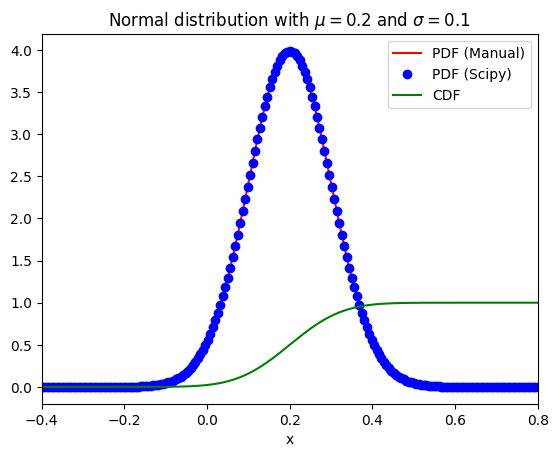

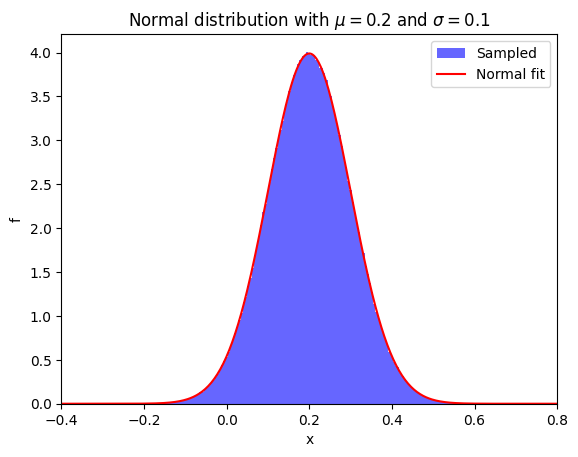

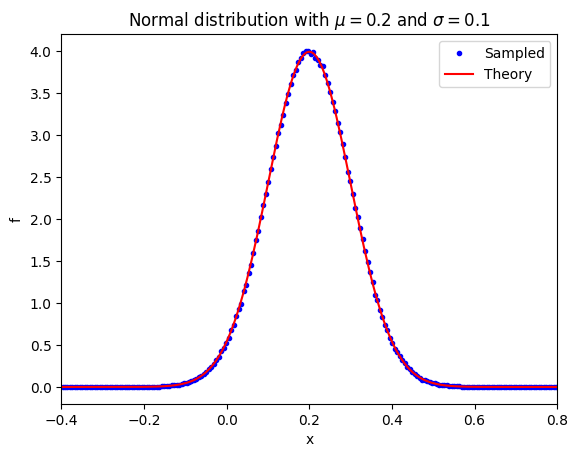

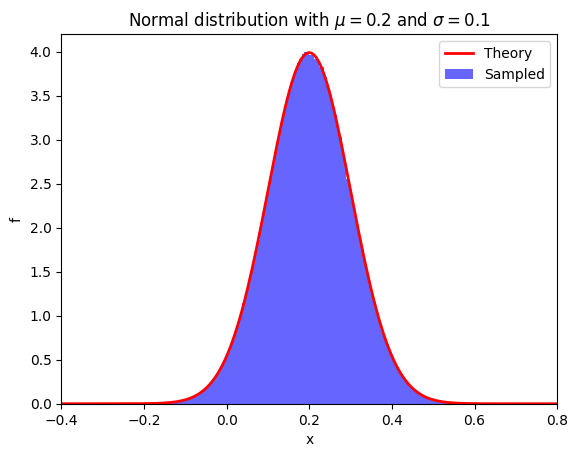

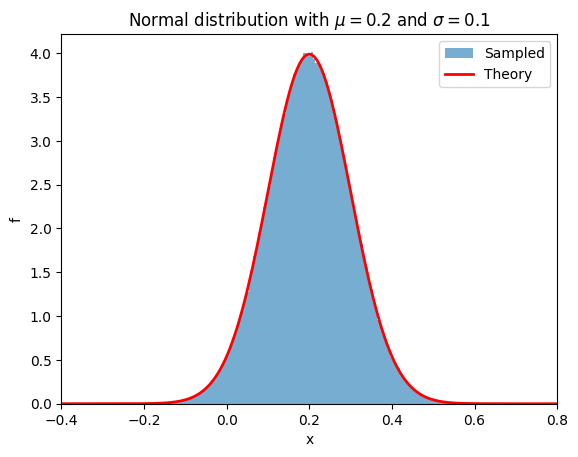

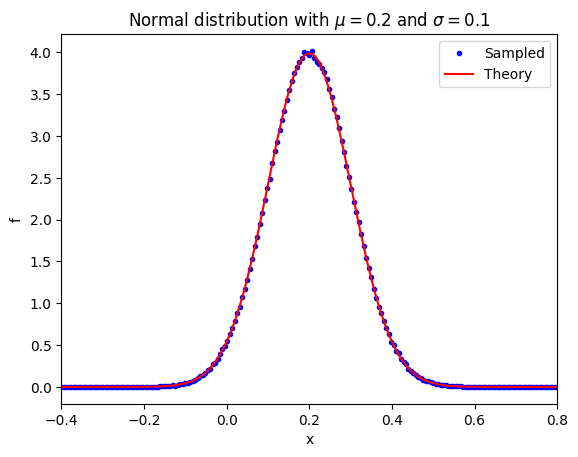

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the parameters
mu = 0.2  # Mean
sigma = 0.1  # Standard deviation
a = -0.4  # Left truncation
b = 0.8  # Right truncation
ngrid = 200  # Number of grid intervals
nsample = 10**6  # Number of random samples

# Define the grid
deltax = (b - a) / ngrid  # Grid step
x = np.arange(a, b + deltax, deltax)  # Grid points (equivalent to a:deltax:b in MATLAB)

# Compute the PDF and CDF
f1 = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-((x - mu) / sigma)**2 / 2)  # Manual computation
f = norm.pdf(x, loc=mu, scale=sigma)  # PDF using scipy.stats
F = norm.cdf(x, loc=mu, scale=sigma)  # CDF using scipy.stats

# Plot the PDF and CDF
plt.figure(1)
plt.plot(x, f1, 'r', label='PDF (Manual)')
plt.plot(x, f, 'bo', label='PDF (Scipy)')
plt.plot(x, F, 'g', label='CDF')
plt.xlim([a, b])
plt.xlabel('x')
plt.legend()
plt.title('Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.savefig('normal.png')
plt.show()

# Sample the normal distribution
X = mu + sigma * np.random.randn(nsample)  # Normal random variables (method 2)

# Histogram and fit
plt.figure(2)
plt.hist(X, bins=ngrid, density=True, alpha=0.6, color='b', label='Sampled')
x_fit = np.linspace(a, b, 500)
f_fit = norm.pdf(x_fit, loc=mu, scale=sigma)
plt.plot(x_fit, f_fit, 'r', label='Normal fit')
plt.xlim([a, b])
plt.xlabel('x')
plt.ylabel('f')
plt.legend()
plt.title('Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.show()

# Normalized histogram (custom bins)
h, edges = np.histogram(X, bins=x, density=False)
h = h / (nsample * deltax)  # Normalize
bin_centers = (edges[:-1] + edges[1:]) / 2

# Line plot of histogram
plt.figure(3)
plt.plot(bin_centers, h, 'b.', label='Sampled', linewidth=2)
plt.plot(x, f, 'r', label='Theory')
plt.xlim([a, b])
plt.xlabel('x')
plt.ylabel('f')
plt.legend()
plt.title('Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.show()

# Bar plot of histogram with theory
plt.figure(4)
plt.bar(bin_centers, h, width=deltax, color='b', alpha=0.6, label='Sampled')
plt.plot(x, f, 'r', linewidth=2, label='Theory')
plt.xlim([a, b])
plt.xlabel('x')
plt.ylabel('f')
plt.legend()
plt.title('Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.show()

# Histogram with edges and PDF overlay
plt.figure(5)
edges = np.concatenate((x - deltax / 2, [x[-1] + deltax / 2]))  # Bin edges
plt.hist(X, bins=edges, density=True, alpha=0.6, label='Sampled')
plt.plot(x, f, 'r', linewidth=2, label='Theory')
plt.xlim([a, b])
plt.xlabel('x')
plt.ylabel('f')
plt.legend()
plt.title('Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.show()

# Line plot of histogram values
h2, _ = np.histogram(X, bins=edges, density=True)
bin_centers = (edges[:-1] + edges[1:]) / 2  # Midpoints of the bins
plt.figure(6)
plt.plot(bin_centers, h2, 'b.', label='Sampled', linewidth=2)
plt.plot(x, f, 'r', label='Theory')
plt.xlim([a, b])
plt.xlabel('x')
plt.ylabel('f')
plt.legend()
plt.title('Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.show()